<a href="https://colab.research.google.com/github/mayurivedpathak01-alt/CodeVedX-Data-Science-Internship/blob/main/Movie_rating_prediction_new.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
url = "https://raw.githubusercontent.com/Shivani142005/CODESOFT/main/IMDb%20Movies%20India.csv"
df = pd.read_csv(url, encoding='latin-1')

print(df.shape)
df.head()

(15509, 10)


,Name,Year,Duration,Genre,Rating,Votes,Director,Actor 1,Actor 2,Actor 3
0,,NaN,NaN,Drama,NaN,NaN,J.S. Randhawa,Manmauji,Birbal,Rajendra Bhatia
1,#Gadhvi (He thought he was Gandhi),(2019),109 min,Drama,7.0,8,Gaurav Bakshi,Rasika Dugal,Vivek Ghamande,Arvind Jangid
2,#Homecoming,(2021),90 min,"Drama, Musical",NaN,NaN,Soumyajit Majumdar,Sayani Gupta,Plabita Borthakur,Roy Angana
3,#Yaaram,(2019),110 min,"Comedy, Romance",4.4,35,Ovais Khan,Prateik,Ishita Raj,Siddhant Kapoor
4,...And Once Again,(2010),105 min,Drama,NaN,NaN,Amol Palekar,Rajat Kapoor,Rituparna Sengupta,Antara Mali


In [3]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15509 entries, 0 to 15508
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Name      15509 non-null  object 
 1   Year      14981 non-null  object 
 2   Duration  7240 non-null   object 
 3   Genre     13632 non-null  object 
 4   Rating    7919 non-null   float64
 5   Votes     7920 non-null   object 
 6   Director  14984 non-null  object 
 7   Actor 1   13892 non-null  object 
 8   Actor 2   13125 non-null  object 
 9   Actor 3   12365 non-null  object 
dtypes: float64(1), object(9)
memory usage: 1.2+ MB


,0
Name,0
Year,528
Duration,8269
Genre,1877
Rating,7590
Votes,7589
Director,525
Actor 1,1617
Actor 2,2384
Actor 3,3144


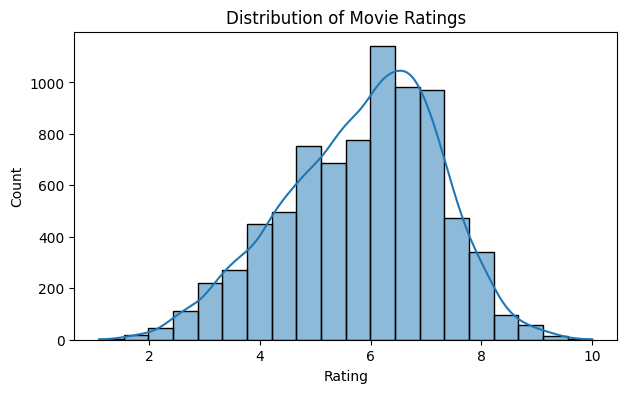

In [4]:
plt.figure(figsize=(7, 4))
sns.histplot(df['Rating'].dropna(), bins=20, kde=True)
plt.title("Distribution of Movie Ratings")
plt.xlabel("Rating")
plt.show()

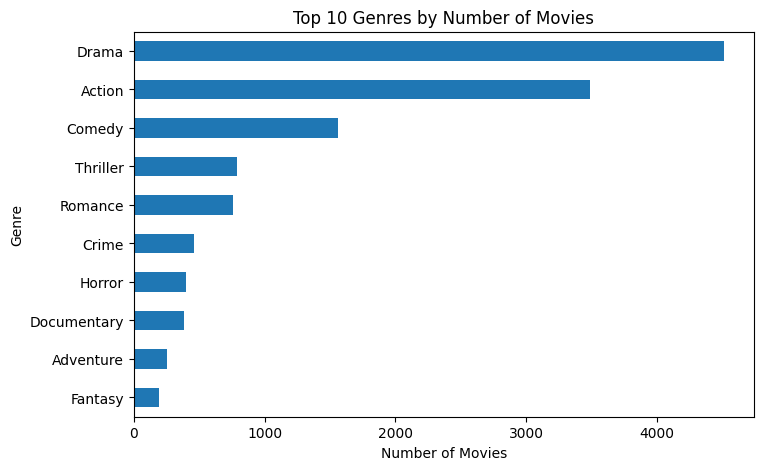

In [5]:
top_genres = df['Genre'].dropna().apply(lambda x: x.split(',')[0].strip()).value_counts().head(10)

plt.figure(figsize=(8, 5))
top_genres.plot(kind='barh')
plt.title("Top 10 Genres by Number of Movies")
plt.xlabel("Number of Movies")
plt.gca().invert_yaxis()
plt.show()

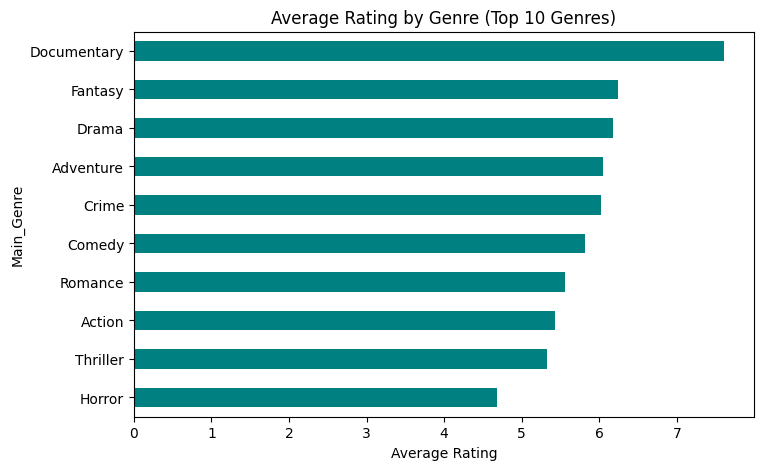

In [6]:
df['Main_Genre'] = df['Genre'].dropna().apply(lambda x: x.split(',')[0].strip())
top_genre_names = top_genres.index

avg_rating_by_genre = df[df['Main_Genre'].isin(top_genre_names)].groupby('Main_Genre')['Rating'].mean().sort_values()

plt.figure(figsize=(8, 5))
avg_rating_by_genre.plot(kind='barh', color='teal')
plt.title("Average Rating by Genre (Top 10 Genres)")
plt.xlabel("Average Rating")
plt.show()

In [7]:
# Drop rows with no rating (can't train without the target)
df = df.dropna(subset=['Rating'])

# Clean Year: remove parentheses, convert to numeric
df['Year'] = df['Year'].astype(str).str.extract(r'(\d{4})')
df['Year'] = pd.to_numeric(df['Year'], errors='coerce')

# Clean Duration: remove " min", convert to numeric
df['Duration'] = df['Duration'].astype(str).str.extract(r'(\d+)')
df['Duration'] = pd.to_numeric(df['Duration'], errors='coerce')

# Clean Votes: remove commas, convert to numeric
df['Votes'] = df['Votes'].astype(str).str.replace(',', '', regex=False)
df['Votes'] = pd.to_numeric(df['Votes'], errors='coerce')

# Fill remaining missing numeric values with median
df['Year'] = df['Year'].fillna(df['Year'].median())
df['Duration'] = df['Duration'].fillna(df['Duration'].median())
df['Votes'] = df['Votes'].fillna(df['Votes'].median())

df.isnull().sum()

,0
Name,0
Year,0
Duration,0
Genre,102
Rating,0
Votes,0
Director,5
Actor 1,125
Actor 2,200
Actor 3,292


In [8]:
# Fill missing categorical values
for col in ['Genre', 'Director', 'Actor 1', 'Actor 2', 'Actor 3']:
    df[col] = df[col].fillna('Unknown')

# Use only the first genre listed
df['Genre'] = df['Genre'].apply(lambda x: x.split(',')[0].strip())

# Frequency encode high-cardinality columns (Director, Actors)
for col in ['Director', 'Actor 1', 'Actor 2', 'Actor 3']:
    freq = df[col].value_counts()
    df[col + '_encoded'] = df[col].map(freq)

# One-hot encode Genre
df = pd.get_dummies(df, columns=['Genre'], drop_first=True)

print("Feature engineering complete.")

Feature engineering complete.


In [9]:
feature_cols = ['Year', 'Duration', 'Votes', 'Director_encoded',
                 'Actor 1_encoded', 'Actor 2_encoded', 'Actor 3_encoded'] + \
                [col for col in df.columns if col.startswith('Genre_')]

X = df[feature_cols]
y = df['Rating']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (6335, 27)
Testing data: (1584, 27)


In [10]:
model = RandomForestRegressor(n_estimators=200, random_state=42)
model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [11]:
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error (MAE):", round(mae, 3))
print("Root Mean Squared Error (RMSE):", round(rmse, 3))
print("R² Score:", round(r2, 3))

Mean Absolute Error (MAE): 0.828
Root Mean Squared Error (RMSE): 1.096
R² Score: 0.354


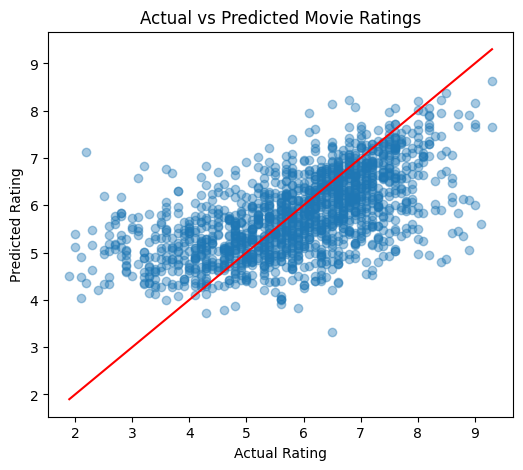

In [12]:
plt.figure(figsize=(6, 5))
plt.scatter(y_test, y_pred, alpha=0.4)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red')
plt.xlabel("Actual Rating")
plt.ylabel("Predicted Rating")
plt.title("Actual vs Predicted Movie Ratings")
plt.show()

Votes                0.252775
Year                 0.223052
Duration             0.112155
Actor 1_encoded      0.076899
Director_encoded     0.072713
Actor 3_encoded      0.069986
Actor 2_encoded      0.069550
Genre_Documentary    0.038096
Genre_Drama          0.021693
Genre_Horror         0.010495
dtype: float64


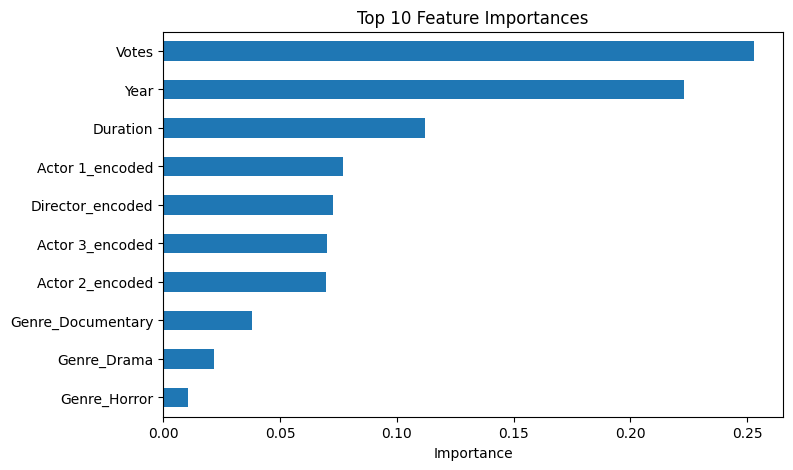

In [13]:
importances = pd.Series(model.feature_importances_, index=feature_cols)
top_features = importances.sort_values(ascending=False).head(10)

print(top_features)

plt.figure(figsize=(8, 5))
top_features.plot(kind='barh')
plt.title("Top 10 Feature Importances")
plt.xlabel("Importance")
plt.gca().invert_yaxis()
plt.show()

In [14]:
results = pd.DataFrame({
    "Actual Rating": y_test.values,
    "Predicted Rating": y_pred
})

print(results.head(20))

results.to_csv("movie_rating_predictions.csv", index=False)
print("Results saved successfully!")

    Actual Rating  Predicted Rating
0             3.3            4.5080
1             5.3            4.8380
2             5.7            5.0995
3             7.2            4.5315
4             3.5            5.8055
5             7.2            5.6805
6             3.8            5.1955
7             6.9            7.0955
8             5.2            5.6095
9             7.4            5.7755
10            4.3            5.9765
11            7.2            6.8050
12            5.6            5.1960
13            3.9            5.1365
14            3.2            5.0155
15            6.4            4.8165
16            5.8            4.6480
17            6.4            6.4165
18            7.6            7.2430
19            2.9            5.2920
Results saved successfully!
